# 3.4PA Supervised Learning on Census Income

Date: May 31, 2026

Student ID: chrlyl2361

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.model_selection import GridSearchCV

import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from datetime import date

student_id = "chrlyl2361"
todays_date = date.today()

display(Markdown("## Step 2: Import Libraries"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

print("Libraries loaded successfully.")

## Step 2: Import Libraries

Date: 2026-05-31

Student ID: chrlyl2361

Libraries loaded successfully.


In [2]:
display(Markdown("## Step 3: Load Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

data = pd.read_csv("census_income_dataset.csv")

print("Dataset Loaded Successfully")
data.head()

## Step 3: Load Dataset

Date: 2026-05-31

Student ID: chrlyl2361

Dataset Loaded Successfully


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
display(Markdown("## Step 4: Explore Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

print("Dataset Information")
print(data.info())

print("\nDataset Description")
display(data.describe(include='all'))

## Step 4: Explore Dataset

Date: 2026-05-31

Student ID: chrlyl2361

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None

Dataset Description


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,47879,4.884200e+04,48842,48842.000000,48842,47876,48842,48842,48842,48842.000000,48842.000000,48842.000000,48568,48842
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,4
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,24720
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [4]:
display(Markdown("## Step 5: Check Missing Values"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

print(data.isnull().sum())

## Step 5: Check Missing Values

Date: 2026-05-31

Student ID: chrlyl2361

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64


In [5]:
display(Markdown("## Step 6: Handle Missing Values"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

data.replace(' ?', np.nan, inplace=True)

data.dropna(inplace=True)

print("Missing values removed.")
print(data.isnull().sum().sum())

## Step 6: Handle Missing Values

Date: 2026-05-31

Student ID: chrlyl2361

Missing values removed.
0


In [6]:
display(Markdown("## Step 7: Remove Duplicate Rows"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

duplicates = data.duplicated().sum()

print(f"Duplicate Rows Found: {duplicates}")

data.drop_duplicates(inplace=True)

print(f"New Shape: {data.shape}")

## Step 7: Remove Duplicate Rows

Date: 2026-05-31

Student ID: chrlyl2361

Duplicate Rows Found: 29
New Shape: (47592, 15)


In [7]:
display(Markdown("## Step 8: Convert Income to Binary"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

data['income'] = data['income'].apply(
    lambda x: 1 if x == '>50K' else 0
)

data['income'].value_counts()

## Step 8: Convert Income to Binary

Date: 2026-05-31

Student ID: chrlyl2361

income
0    39753
1     7839
Name: count, dtype: int64

In [8]:
display(Markdown("## Step 9: One-Hot Encoding"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

data = pd.get_dummies(data, drop_first=True)

print("One-Hot Encoding Complete")

data.head()

## Step 9: One-Hot Encoding

Date: 2026-05-31

Student ID: chrlyl2361

One-Hot Encoding Complete


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,2174,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
display(Markdown("## Step 10: Define Features and Target"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

X = data.drop('income', axis=1)
y = data['income']

print(X.shape)
print(y.shape)

## Step 10: Define Features and Target

Date: 2026-05-31

Student ID: chrlyl2361

(47592, 100)
(47592,)


In [10]:
display(Markdown("## Step 11: Train-Test Split"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

## Step 11: Train-Test Split

Date: 2026-05-31

Student ID: chrlyl2361

(33314, 100)
(14278, 100)


In [11]:
display(Markdown("## Step 12: Feature Scaling"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Complete")

## Step 12: Feature Scaling

Date: 2026-05-31

Student ID: chrlyl2361

Scaling Complete


In [12]:
display(Markdown("## Step 13: Train KNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("KNN Model Trained Successfully")

## Step 13: Train KNN Model

Date: 2026-05-31

Student ID: chrlyl2361

KNN Model Trained Successfully


In [13]:
display(Markdown("## Step 14: Initial Predictions"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

print("First 20 Predictions")

print(y_pred[:20])

## Step 14: Initial Predictions

Date: 2026-05-31

Student ID: chrlyl2361

First 20 Predictions
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [14]:
display(Markdown("## Step 15: Evaluate Original Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix")
print(cm)

## Step 15: Evaluate Original Model

Date: 2026-05-31

Student ID: chrlyl2361

Accuracy: 0.8289676425269645
Precision: 0.48435544430538174
Recall: 0.32357859531772576
F1 Score: 0.3879699248120301

Confusion Matrix
[[11062   824]
 [ 1618   774]]


In [15]:
display(Markdown("## Step 16: Hyperparameter Tuning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

param_grid = {
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan','minkowski']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters")

print(grid.best_params_)

## Step 16: Hyperparameter Tuning

Date: 2026-05-31

Student ID: chrlyl2361

Best Parameters
{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}


In [16]:
display(Markdown("## Step 17: Refit Tuned Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

best_knn = grid.best_estimator_

best_knn.fit(X_train_scaled, y_train)

y_pred_tuned = best_knn.predict(X_test_scaled)

print("Tuned Model Ready")

## Step 17: Refit Tuned Model

Date: 2026-05-31

Student ID: chrlyl2361

Tuned Model Ready


In [17]:
display(Markdown("## Step 18: Evaluate Tuned Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

precision_tuned = precision_score(y_test, y_pred_tuned)

recall_tuned = recall_score(y_test, y_pred_tuned)

f1_tuned = f1_score(y_test, y_pred_tuned)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print("Accuracy:", accuracy_tuned)
print("Precision:", precision_tuned)
print("Recall:", recall_tuned)
print("F1 Score:", f1_tuned)

print("\nConfusion Matrix")
print(cm_tuned)

## Step 18: Evaluate Tuned Model

Date: 2026-05-31

Student ID: chrlyl2361

Accuracy: 0.8354111220058832
Precision: 0.5154639175257731
Recall: 0.29264214046822745
F1 Score: 0.37333333333333335

Confusion Matrix
[[11228   658]
 [ 1692   700]]


## Step 19: Confusion Matrix Heatmap

Date: 2026-05-31

Student ID: chrlyl2361

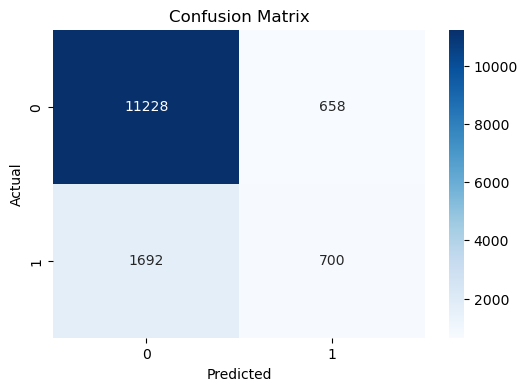

In [18]:
display(Markdown("## Step 19: Confusion Matrix Heatmap"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Step 20: ROC Curve and AUC

Date: 2026-05-31

Student ID: chrlyl2361

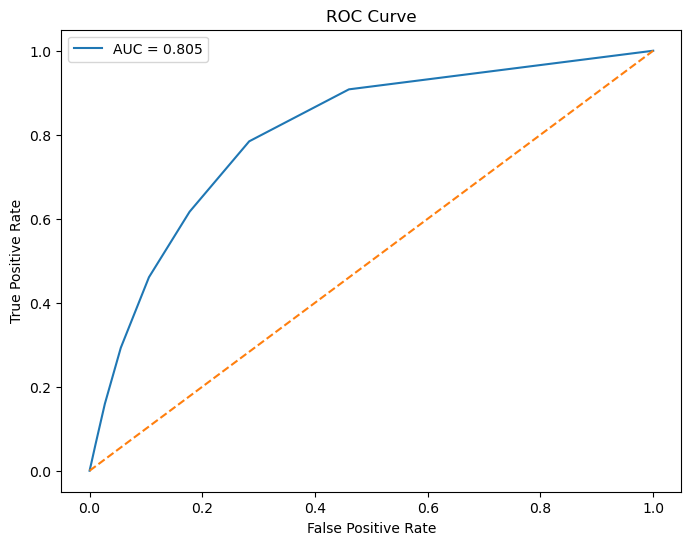

AUC Score: 0.8050573782877131


In [19]:
display(Markdown("## Step 20: ROC Curve and AUC"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

y_prob = best_knn.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score:", roc_auc)

## Analysis and Interpretation

### Question 1
How well does the K-Nearest Neighbors model perform on the Census Income dataset before and after hyperparameter tuning?

The initial K-Nearest Neighbors (KNN) model achieved an accuracy of 82.90%, with a precision of 48.44%, recall of 32.36%, and an F1 score of 38.80%. After applying GridSearchCV hyperparameter tuning, the model's accuracy improved to 83.54%, and precision increased to 51.55%. However, recall decreased slightly from 32.36% to 29.26%, and the F1 score decreased from 38.80% to 37.33%.

Overall, hyperparameter tuning resulted in a small improvement in overall accuracy and precision, indicating that the tuned model was slightly better at correctly identifying individuals earning more than $50,000. The confusion matrix also showed fewer false positives after tuning. While the improvement was modest, the tuned model provided better overall classification performance.

### Question 2
Which hyperparameters were selected as optimal by GridSearchCV, and how did they affect the model performance?

GridSearchCV selected the following optimal hyperparameters:

- n_neighbors = 9
- weights = 'uniform'
- metric = 'euclidean'

Increasing the number of neighbors from the default value of 5 to 9 helped the model make predictions based on a larger group of nearby observations, which reduced sensitivity to noise in the dataset. The Euclidean distance metric was identified as the most effective method for measuring similarity between observations, and uniform weighting treated all neighboring observations equally during classification.

These optimized parameters increased the model's accuracy from 82.90% to 83.54% and improved precision from 48.44% to 51.55%. Although recall decreased slightly, the tuned model demonstrated better overall predictive performance and achieved an AUC score of 0.805, indicating good ability to distinguish between income classes.